## Tugas 9 - Predicting Power Consumption using Linear Regression - Supervised Learning

> Download dataset (train_energy_data.csv dan test_energy_data.csv) disini : https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression?select=test_energy_data.csv

> Dataset merupakan data konsumsi daya berdasarkan banyak variabel lainnya.

> Dataset udah di-split menjadi: ``` train_energy_data.csv ``` dan ``` test_energy_data.csv ```

> Isi insight menggunakan bahasa sendiri dan bukan AI - generated.


---

Nama lengkap : Aditya Nugraha Pratama Saiya

Asal universitas : Universitas Riau

---

### 0. Import Module yang diperlukan

> Import module yang diperlukan untuk mendukung seluruh kegiatan

In [212]:
# Install dependensi
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [213]:
# Import library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────

# MinMaxScaler: normalisasi data ke range 0-1
# Contoh: [100, 200, 300] → [0.0, 0.5, 1.0]
# Tujuan: biar model tidak bias ke nilai besar
from sklearn.preprocessing import MinMaxScaler

# train_test_split: membagi dataset menjadi data training dan data testing
# Tujuan: agar model belajar dari data training, lalu dievaluasi di data testing
# Tanpa ini model bisa 'ngafal', bukan 'belajar'
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────
# MODEL MACHINE LEARNING
# ─────────────────────────────────────────────

# LinearRegression: model untuk prediksi nilai kontinu
# Konsep: mencari garis terbaik → y = mx + b
# Cocok untuk: prediksi harga, suhu, konsumsi daya, dll
from sklearn.linear_model import LinearRegression

# ─────────────────────────────────────────────
# EVALUASI MODEL
# ─────────────────────────────────────────────

# mean_absolute_error (MAE): rata-rata selisih absolut prediksi vs nilai asli
# mean_squared_error (MSE): seperti MAE tapi error dikuadratkan (menghukum error besar)
# r2_score (R²): seberapa baik model menjelaskan data (0 = buruk, 1 = sempurna)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─────────────────────────────────────────────
# SIMPAN MODEL
# ─────────────────────────────────────────────

# joblib: menyimpan model ke file .pkl agar tidak perlu training ulang
# Contoh simpan : joblib.dump(model, 'model.pkl')
# Contoh load   : model = joblib.load('model.pkl')
import joblib

# ─────────────────────────────────────────────
# PENGATURAN TAMPILAN
# ─────────────────────────────────────────────

# Sembunyikan warning yang tidak penting
import warnings
warnings.filterwarnings('ignore')

# Set tema grafik dan tampilkan plot langsung di notebook
sns.set_style('whitegrid')
%matplotlib inline

### 1. Problem Identification

> Jelaskan permasalahan yang ingin diselesaikan dari dataset ini. Contoh: "Bagaimana memprediksi konsumsi energi bangunan berdasarkan karakteristik bangunan dan lingkungan sekitar."

### Problem Identification

#### Permasalahan
Bagaimana memprediksi konsumsi energi bangunan berdasarkan karakteristik
bangunan dan kondisi lingkungan sekitar menggunakan model Linear Regression?

#### Latar Belakang
Konsumsi energi sangat dipengaruhi oleh jenis bangunan, luas area, jumlah
penghuni, peralatan listrik yang digunakan, suhu lingkungan, serta hari
dalam seminggu. Setiap jenis bangunan memiliki pola konsumsi yang berbeda:

- **Residential (Hunian):**
  Konsumsi energi dipengaruhi oleh luas bangunan, jumlah penghuni,
  jumlah peralatan listrik, dan suhu. Saat suhu panas, penggunaan AC
  meningkat. Saat malam, lampu dan kipas/AC aktif lebih lama.

- **Commercial (Komersial):**
  Konsumsi tinggi pada Weekday karena gedung beroperasi penuh seharian.
  Pada Weekend gedung cenderung tidak dipakai sehingga konsumsi turun
  drastis. Luas bangunan dan jumlah peralatan juga sangat berpengaruh.

- **Industrial (Industri):**
  Konsumsi bergantung pada jumlah peralatan mesin yang aktif. Suhu
  lingkungan berpengaruh karena AC harus terus menyala untuk menjaga
  mesin tidak overheat. Weekend biasanya libur sehingga konsumsi lebih
  rendah.

#### Target Prediksi
Variabel yang ingin diprediksi: **Energy Consumption** (konsumsi daya listrik)

#### Fitur yang Digunakan
| Fitur | Pengaruh |
|-------|----------|
| Building Type | Menentukan pola konsumsi dasar |
| Square Footage | Makin luas, makin banyak energi dibutuhkan |
| Number of Occupants | Makin banyak penghuni, konsumsi makin tinggi |
| Appliances Used | Lebih banyak alat listrik = lebih besar konsumsi |
| Average Temperature | Suhu tinggi → AC aktif → konsumsi naik |
| Day of Week | Weekday lebih tinggi dari Weekend (terutama komersial) |

### 2. Data Collection

> Di sini silakan muat data dan menuliskan deskripsi awal.

#### 2.1 training

In [214]:
# TODO: Load dataset dari file CSV yang sudah diunduh
df_train = pd.read_csv('.//EDA_Dataset/train_energy_data.csv')

In [215]:
# TODO: Tampilkan statistik deskriptif (.describe())
df_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [216]:
# TODO: Tampilkan informasi tipe data (.info())
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [217]:
# TODO: Hitung mean, median, modus, variansi, dan standar deviasi pada kolom numerik

# Cek kolom apa saja yang tipe datanya numerik
df_train.select_dtypes(include=['number']).columns

# Column Building Type & Day of Week tipe datanya objek, sehingga tidak termasuk numerik

Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
       'Average Temperature', 'Energy Consumption'],
      dtype='object')

In [218]:
# Menghitung rata-rata dari kolom yang bertipe numerik
df_train.mean(numeric_only=True)

Square Footage         25462.38800
Number of Occupants       48.37200
Appliances Used           25.60600
Average Temperature       22.61139
Energy Consumption      4166.25257
dtype: float64

In [219]:
# Menghitung median dari kolom yang bertipe numerik
df_train.median(numeric_only=True)

Square Footage         25477.000
Number of Occupants       47.000
Appliances Used           26.000
Average Temperature       22.815
Energy Consumption      4175.730
dtype: float64

In [220]:
# Menghitung variansi dari kolom yang bertipe numerik
df_train.var(numeric_only=True)

# e+12 = × 10^12
# artinya geser koma 12 langkah ke kanan
# contoh: 1e+12 = 1,000,000,000,000

Square Footage         2.043343e+08
Number of Occupants    8.445982e+02
Appliances Used        1.989557e+02
Average Temperature    5.097878e+01
Energy Consumption     8.710733e+05
dtype: float64

In [221]:
# Menghitung standar deviasi dari kolom yang bertipe numerik
df_train.std(numeric_only=True)

Square Footage         14294.554000
Number of Occupants       29.061972
Appliances Used           14.105166
Average Temperature        7.139943
Energy Consumption       933.313064
dtype: float64

#### 2.2 Testing

In [222]:
# TODO: Load dataset dari file CSV yang sudah diunduh
df_test = pd.read_csv('.//EDA_Dataset/test_energy_data.csv')

In [223]:
# TODO: Tampilkan statistik deskriptif (.describe())
df_test.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


In [224]:
# TODO: Tampilkan informasi tipe data (.info())
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [225]:
# TODO: Hitung mean, median, modus, variansi, dan standar deviasi pada kolom numerik

# Cek kolom apa saja yang tipe datanya numerik
df_test.select_dtypes(include=['number']).columns

# Column Building Type & Day of Week tipe datanya objek, sehingga tidak termasuk numerik

Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
       'Average Temperature', 'Energy Consumption'],
      dtype='object')

In [226]:
# Menghitung rata-rata dari kolom yang bertipe numerik
df_test.mean(numeric_only=True)

Square Footage         25881.9200
Number of Occupants       47.2300
Appliances Used           26.9700
Average Temperature       22.0433
Energy Consumption      4187.5783
dtype: float64

In [227]:
# Menghitung median dari kolom yang bertipe numerik
df_test.median(numeric_only=True)

Square Footage         27582.50
Number of Occupants       47.00
Appliances Used           27.50
Average Temperature       21.97
Energy Consumption      4249.39
dtype: float64

In [228]:
# Menghitung variansi dari kolom yang bertipe numerik
df_test.var(numeric_only=True)


# e+12 = × 10^12
# artinya geser koma 12 langkah ke kanan
# contoh: 1e+12 = 1,000,000,000,000

Square Footage         1.879936e+08
Number of Occupants    8.943405e+02
Appliances Used        2.027163e+02
Average Temperature    4.841309e+01
Energy Consumption     6.931559e+05
dtype: float64

### Insight - Data Collection

#### Gambaran Umum Dataset
- Dataset terbagi menjadi **data training (1.000 baris)** dan **data testing (100 baris)**
  dengan **7 kolom** yang sama di kedua dataset
- **Tidak ditemukan missing value** pada kedua dataset — data siap diproses tanpa imputasi
- Terdapat **5 kolom numerik** (`Square Footage`, `Number of Occupants`,
  `Appliances Used`, `Average Temperature`, `Energy Consumption`) dan
  **2 kolom kategorikal** (`Building Type`, `Day of Week`)

#### Perbandingan Statistik Training vs Testing
| Kolom | Mean Train | Mean Test | Median Train | Median Test |
|-------|-----------|-----------|--------------|-------------|
| Square Footage | 25.462 | 25.882 | 25.477 | 27.583 |
| Number of Occupants | 48,37 | 47,23 | 47 | 47 |
| Appliances Used | 25,61 | 26,97 | 26 | 27,5 |
| Average Temperature | 22,61°C | 22,04°C | 22,82°C | 21,97°C |
| Energy Consumption | 4.166,25 | 4.187,58 | 4.175,73 | 4.249,39 |

#### Temuan Penting
- Nilai **mean ≈ median** pada semua kolom numerik menunjukkan distribusi yang
  **relatif simetris** tanpa outlier ekstrem
- **Variansi Square Footage sangat besar** (train: 2,04×10⁸, test: 1,88×10⁸)
  karena rentang data sangat lebar — dari 560 hingga 49.997 kaki persegi
- Distribusi data training dan testing **sangat konsisten** —
  selisih mean Energy Consumption hanya sekitar 21 unit (4.166 vs 4.188)
- **Standar deviasi Energy Consumption** cukup besar (train: 933, test: 833),
  menunjukkan variasi konsumsi energi yang signifikan antar bangunan

### 3. Data Preprocessing

> Tahapan membersihkan data dan menangani data yang hilang atau rusak. Gunakan metode yang diperlukan.

In [229]:
# ─────────────────────────────────────────────
# CEK MISSING VALUES
# ─────────────────────────────────────────────

# Cek missing values pada data training
print("=== Missing Values - Training ===")
print(df_train.isnull().sum())

print("\n=== Missing Values - Testing ===")
print(df_test.isnull().sum())

# Tidak ada missing values → tidak perlu imputasi atau drop

=== Missing Values - Training ===
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

=== Missing Values - Testing ===
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


In [230]:
# ─────────────────────────────────────────────
# ENCODING KOLOM KATEGORIKAL
# ─────────────────────────────────────────────

# Day of Week: Weekday=1, Weekend=0 (binary encoding)
day_map = {
    'Weekday': 1, 
    'Weekend': 0
    }

df_train['Day of Week'] = df_train['Day of Week'].map(day_map)
df_test['Day of Week']  = df_test['Day of Week'].map(day_map)

# Building Type: One-Hot Encoding (3 kategori → 2 kolom dummy)
# drop_first=True untuk menghindari multikolinearitas
df_train = pd.get_dummies(df_train, columns=['Building Type'], drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=['Building Type'], drop_first=True)

# Pastikan kolom train dan test sama setelah encoding
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

print("Kolom setelah encoding:")
print(df_train.columns.tolist())

Kolom setelah encoding:
['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week', 'Energy Consumption', 'Building Type_Industrial', 'Building Type_Residential']


In [231]:
# ─────────────────────────────────────────────
# CEK FORMAT DATA
# ─────────────────────────────────────────────

# Pastikan semua kolom sudah numerik
print("=== Tipe Data Training ===")
print(df_train.dtypes)

print("\n=== Tipe Data Testing ===")
print(df_test.dtypes)

=== Tipe Data Training ===
Square Footage                 int64
Number of Occupants            int64
Appliances Used                int64
Average Temperature          float64
Day of Week                    int64
Energy Consumption           float64
Building Type_Industrial        bool
Building Type_Residential       bool
dtype: object

=== Tipe Data Testing ===
Square Footage                 int64
Number of Occupants            int64
Appliances Used                int64
Average Temperature          float64
Day of Week                    int64
Energy Consumption           float64
Building Type_Industrial        bool
Building Type_Residential       bool
dtype: object


In [232]:
# ─────────────────────────────────────────────
# NORMALISASI DATA
# ─────────────────────────────────────────────

# Pisahkan fitur (X) dan target (y)
# Target tidak dinormalisasi agar hasil prediksi tetap terbaca
X_train = df_train.drop(columns=['Energy Consumption']) # Ambil SEMUA kolom KECUALI Energy Consumption
y_train = df_train['Energy Consumption']

X_test  = df_test.drop(columns=['Energy Consumption']) # Ambil SEMUA kolom KECUALI Energy Consumption
y_test  = df_test['Energy Consumption']

# Fit scaler HANYA dari data training, lalu transform keduanya
# Tujuan: agar tidak ada kebocoran data (data leakage)
scaler  = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # belajar + ubah
X_test_scaled  = scaler.transform(X_test)        # ubah saja

print("Shape X_train setelah scaling:", X_train_scaled.shape)
print("Shape X_test  setelah scaling:", X_test_scaled.shape)

Shape X_train setelah scaling: (1000, 7)
Shape X_test  setelah scaling: (100, 7)


### Insight - Data Preprocessing

#### Missing Values
- Tidak ditemukan missing value pada **data training maupun testing** (semua = 0)
- Tidak diperlukan proses imputasi atau penghapusan baris

#### Encoding Kategorikal
- Kolom `Day of Week` diubah menjadi **binary** → Weekday=1, Weekend=0
- Kolom `Building Type` diubah menjadi **2 kolom dummy** menggunakan One-Hot Encoding:
  - `Building Type_Industrial` → 1 jika Industrial, 0 jika tidak
  - `Building Type_Residential` → 1 jika Residential, 0 jika tidak
  - Jika keduanya = 0, maka bangunan tersebut **Commercial** (baseline)
- `drop_first=True` digunakan untuk menghindari multikolinearitas

#### Format Data
- Semua kolom numerik bertipe `int64` dan `float64` — sesuai untuk modeling
- Kolom `Building Type_Industrial` dan `Building Type_Residential` bertipe `bool`,
  namun tetap valid karena scikit-learn membaca `True/False` sebagai `1/0`
- Total **8 kolom** setelah encoding (7 fitur + 1 target)

#### Normalisasi
- `MinMaxScaler` di-**fit hanya pada data training**, lalu di-transform ke keduanya
- Hal ini mencegah **data leakage** — model tidak "mengintip" data testing
- Hasil: `X_train_scaled (1000, 7)` dan `X_test_scaled (100, 7)` —
  jumlah fitur sama, siap masuk ke model

### 4. EDA dan Visualisasi Data

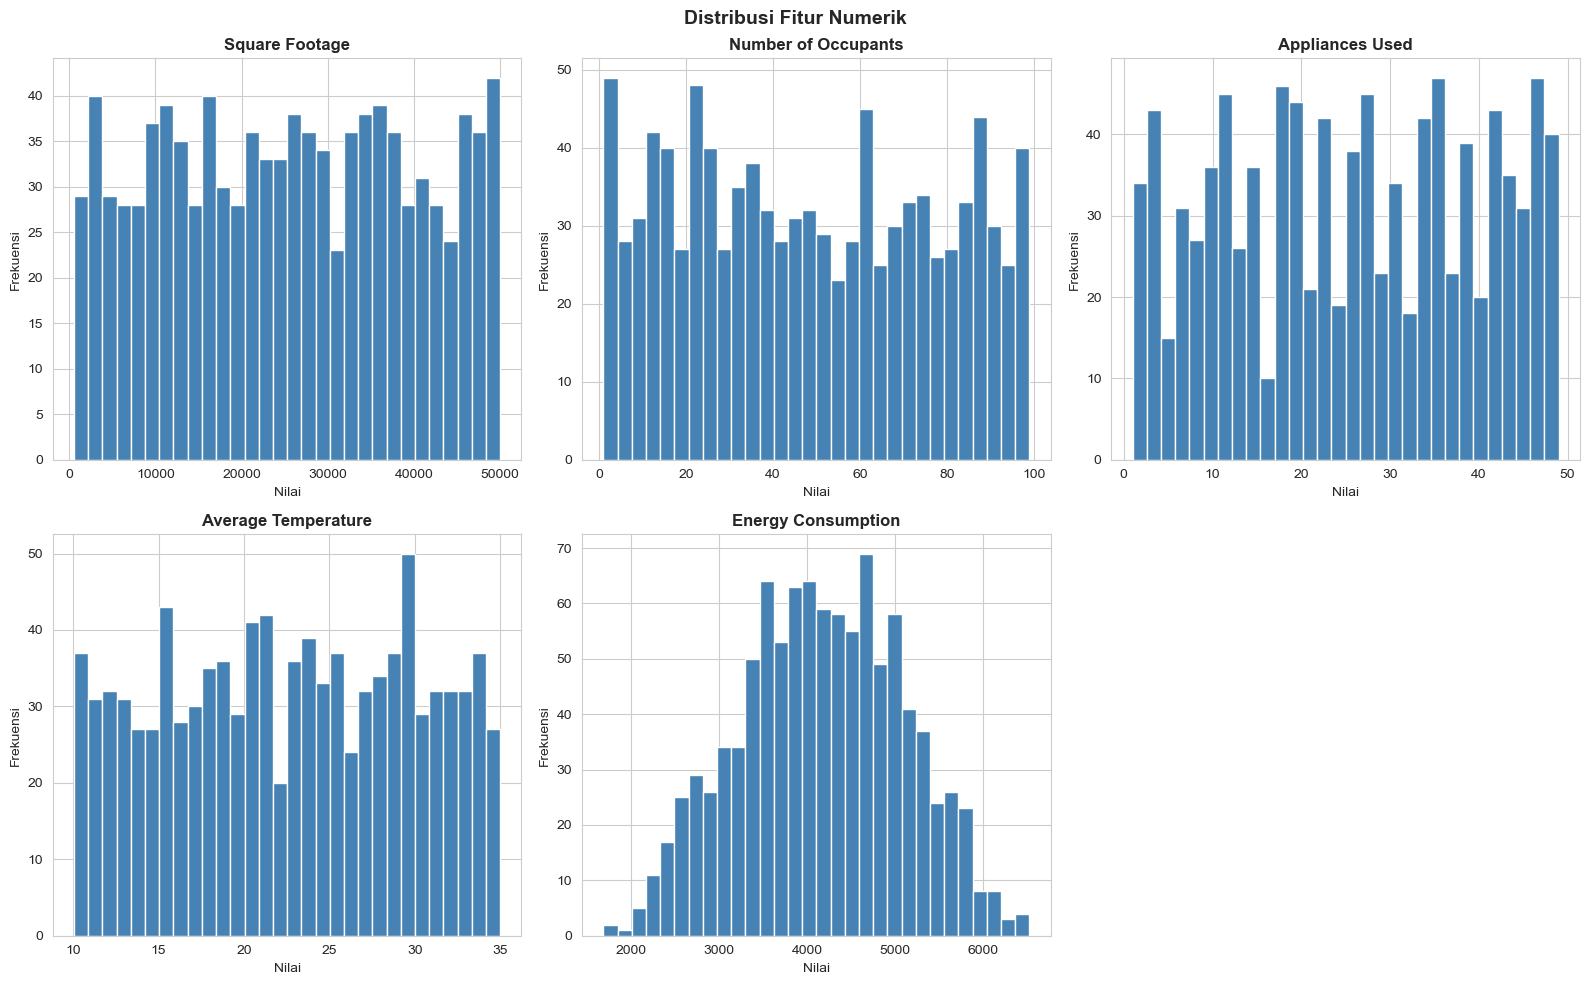

In [233]:
# Analisis Univariat: distribusi setiap fitur numerik
df_ori = pd.read_csv('.//EDA_Dataset/train_energy_data.csv')

kolom_numerik = ['Square Footage', 'Number of Occupants',
                 'Appliances Used', 'Average Temperature', 'Energy Consumption']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    axes[i].hist(df_ori[kolom], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(kolom, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

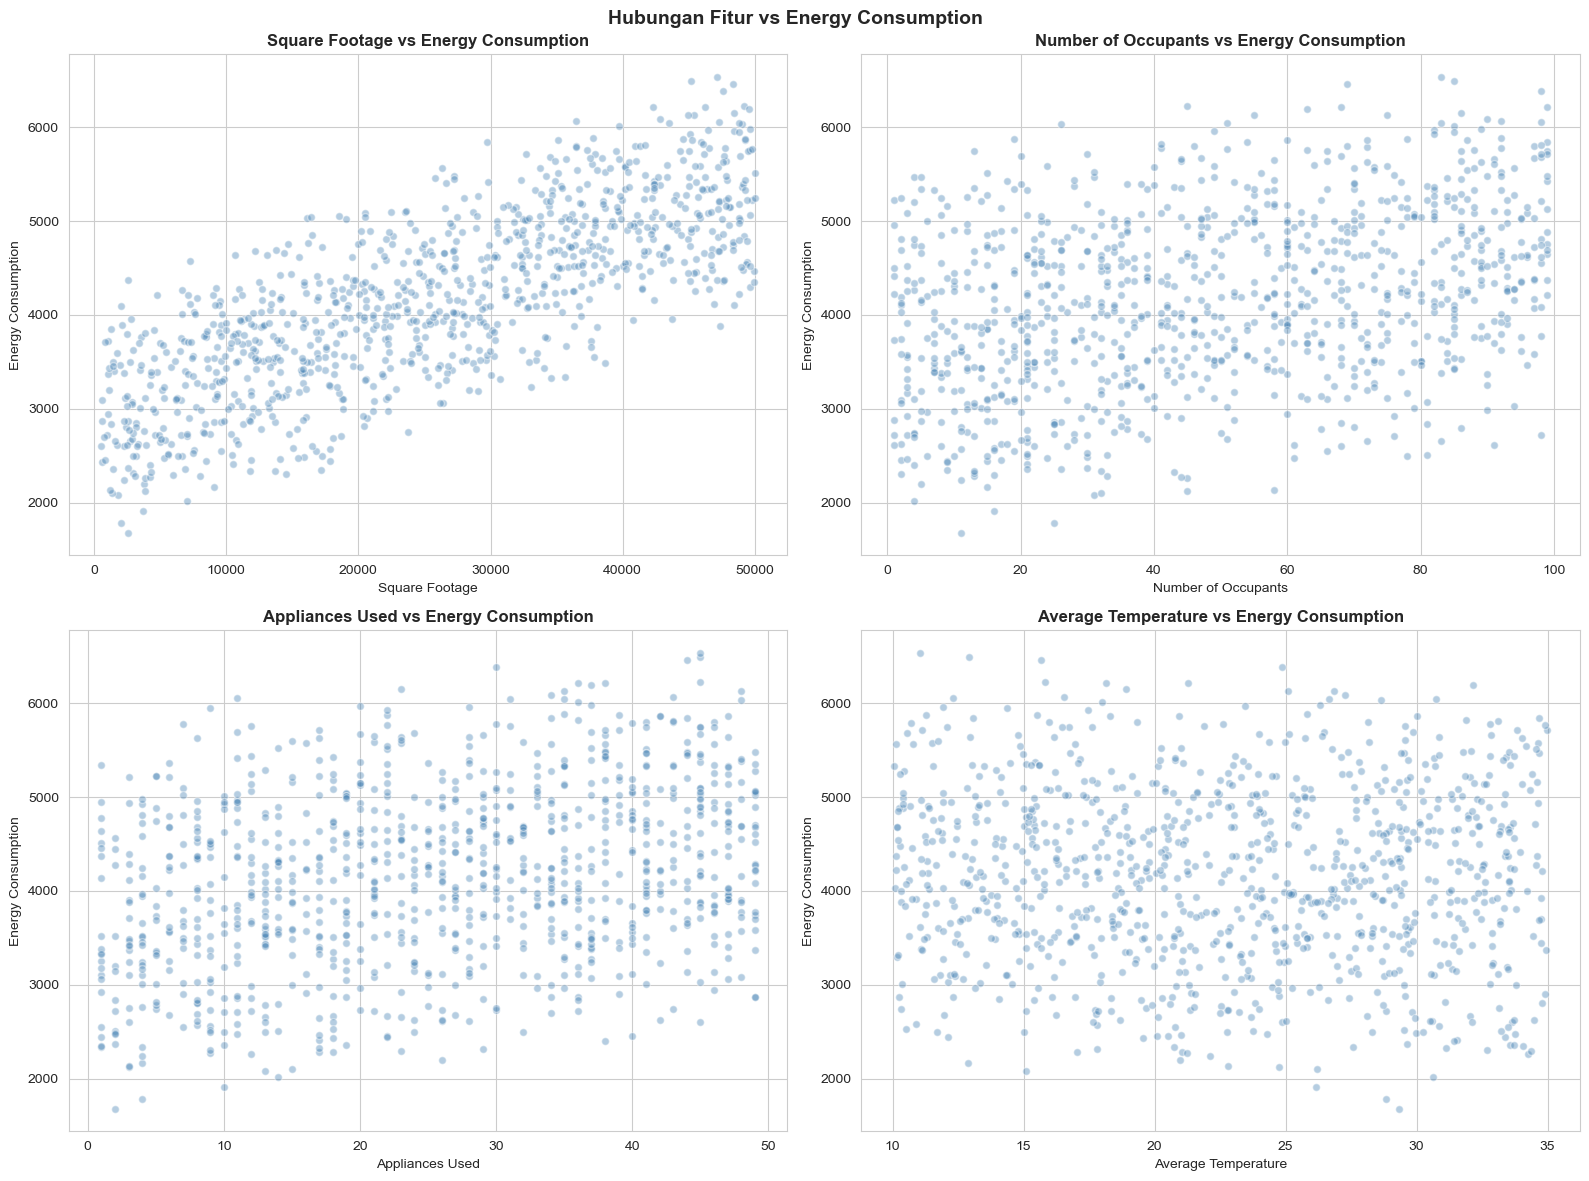

In [234]:
# Analisis Bivariat: hubungan setiap fitur numerik dengan Energy Consumption
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hubungan Fitur vs Energy Consumption', fontsize=14, fontweight='bold')

fitur = ['Square Footage', 'Number of Occupants',
         'Appliances Used', 'Average Temperature']

for i, kolom in enumerate(fitur):
    ax = axes[i // 2][i % 2]
    ax.scatter(df_ori[kolom], df_ori['Energy Consumption'],
               alpha=0.4, color='steelblue', edgecolors='white', s=30)
    ax.set_xlabel(kolom)
    ax.set_ylabel('Energy Consumption')
    ax.set_title(f'{kolom} vs Energy Consumption', fontweight='bold')

plt.tight_layout()
plt.show()

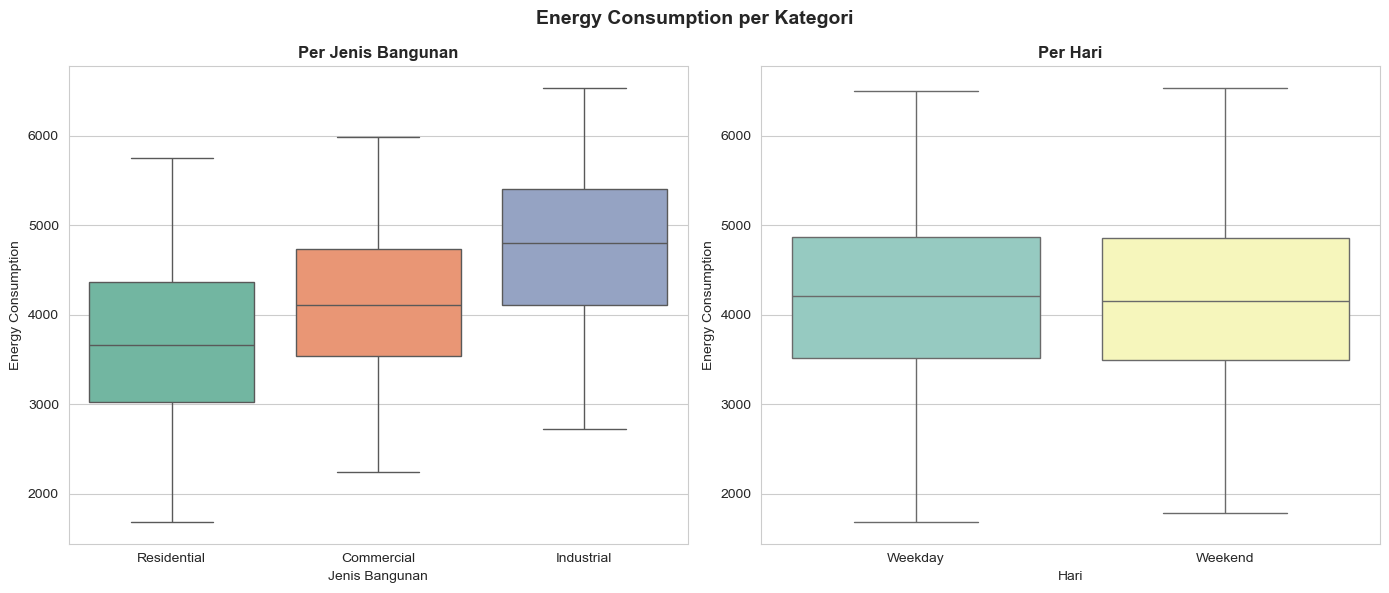

In [235]:
# Boxplot: Energy Consumption berdasarkan kolom kategorikal
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Energy Consumption per Kategori', fontsize=14, fontweight='bold')

# Per Building Type
sns.boxplot(data=df_ori, x='Building Type', y='Energy Consumption',
            palette='Set2', ax=axes[0])
axes[0].set_title('Per Jenis Bangunan', fontweight='bold')
axes[0].set_xlabel('Jenis Bangunan')
axes[0].set_ylabel('Energy Consumption')

# Per Day of Week
sns.boxplot(data=df_ori, x='Day of Week', y='Energy Consumption',
            palette='Set3', ax=axes[1])
axes[1].set_title('Per Hari', fontweight='bold')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Energy Consumption')

plt.tight_layout()
plt.show()

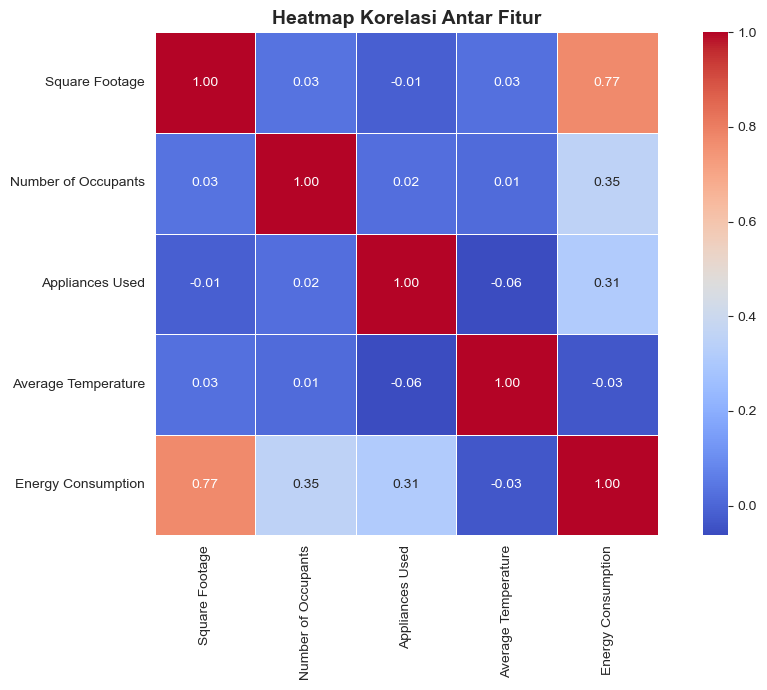

In [236]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(10, 7))
korelasi = df_ori[kolom_numerik].corr()

sns.heatmap(korelasi,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)

plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

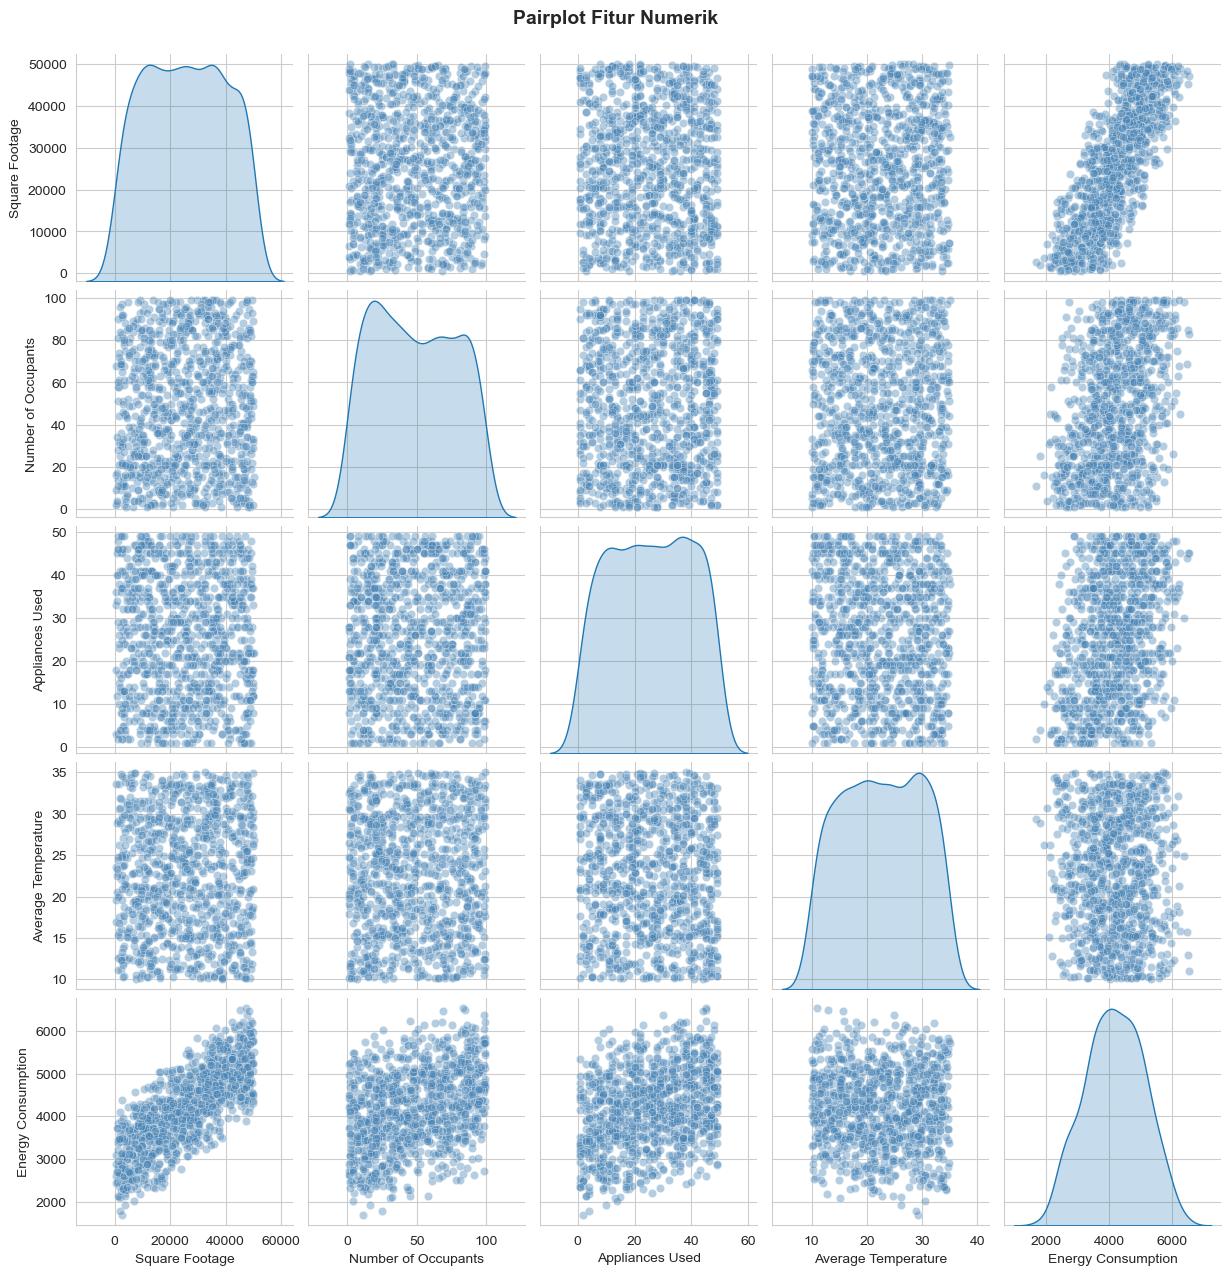

In [237]:
# Pairplot: hubungan antar semua fitur sekaligus
sns.pairplot(df_ori[kolom_numerik],
             diag_kind='kde',
             plot_kws={'alpha': 0.4, 'color': 'steelblue'})

plt.suptitle('Pairplot Fitur Numerik', y=1.02, fontsize=14, fontweight='bold')
plt.show()

=== Korelasi dengan Energy Consumption ===
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature   -0.034487
Name: Energy Consumption, dtype: float64


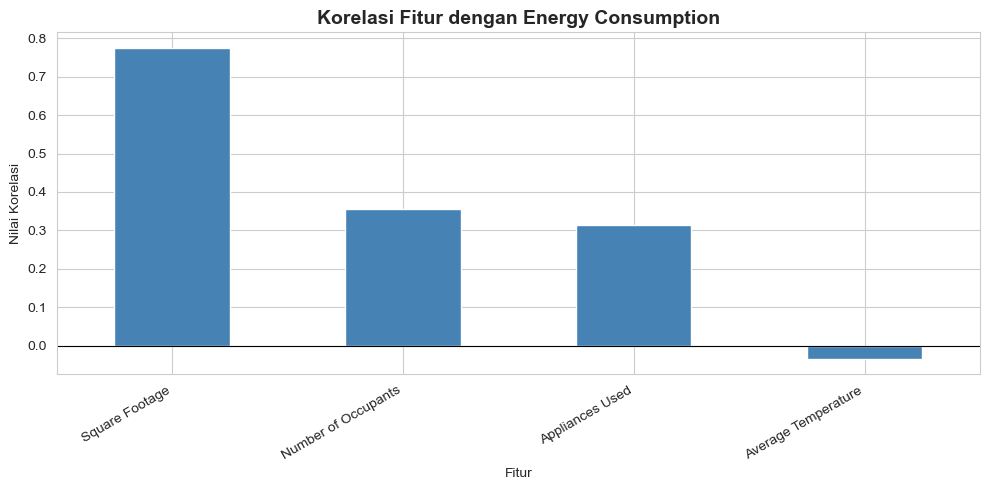

In [238]:
# Identifikasi fitur yang paling berkorelasi dengan Energy Consumption
print("=== Korelasi dengan Energy Consumption ===")
korelasi_target = df_ori[kolom_numerik].corr()['Energy Consumption'].drop('Energy Consumption')
korelasi_target = korelasi_target.sort_values(ascending=False)
print(korelasi_target)

# Visualisasi bar chart korelasi
plt.figure(figsize=(10, 5))
korelasi_target.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Korelasi Fitur dengan Energy Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Nilai Korelasi')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Insight - EDA dan Visualisasi Data

#### Analisis Univariat (Distribusi Fitur)
- **Square Footage** terdistribusi merata (uniform) dari 0 hingga 50.000 kaki persegi,
  menunjukkan dataset mencakup semua ukuran bangunan secara seimbang
- **Number of Occupants** dan **Appliances Used** memiliki distribusi yang relatif
  merata dengan sedikit penurunan di ujung atas
- **Average Temperature** terdistribusi merata antara 10°C hingga 35°C
- **Energy Consumption** membentuk distribusi **normal (bell curve)** dengan
  puncak di sekitar 4.000–4.500 — ini pertanda baik untuk pemodelan regresi

#### Analisis Bivariat (Scatter Plot)
- **Square Footage vs Energy Consumption** menunjukkan tren positif yang jelas —
  semakin luas bangunan, semakin tinggi konsumsi energinya
- **Number of Occupants vs Energy Consumption** menunjukkan tren positif lemah —
  lebih banyak penghuni sedikit meningkatkan konsumsi energi
- **Appliances Used vs Energy Consumption** menunjukkan tren positif lemah —
  lebih banyak peralatan listrik sedikit meningkatkan konsumsi
- **Average Temperature vs Energy Consumption** tidak menunjukkan tren yang jelas —
  titik data tersebar merata tanpa pola

#### Analisis Bivariat (Boxplot Kategorikal)
- **Industrial** memiliki median konsumsi energi tertinggi (~4.800),
  diikuti **Commercial** (~4.200), lalu **Residential** (~3.700)
- **Residential** memiliki rentang data paling lebar — konsumsi sangat bervariasi
  tergantung ukuran dan kebutuhan masing-masing hunian
- **Weekday vs Weekend** tidak menunjukkan perbedaan signifikan —
  median konsumsi hampir sama, menandakan hari tidak terlalu mempengaruhi konsumsi

#### Analisis Multivariat (Pairplot)
- Tidak terlihat korelasi kuat antar fitur input satu sama lain —
  fitur-fitur bersifat **independen**, baik untuk model Linear Regression
- Hanya **Square Footage** yang terlihat jelas memiliki pola linear
  terhadap Energy Consumption di pairplot

#### Heatmap Korelasi
| Fitur | Korelasi dengan Energy Consumption |
|-------|-----------------------------------|
| Square Footage | **0.77** (kuat) |
| Number of Occupants | **0.35** (sedang) |
| Appliances Used | **0.31** (sedang) |
| Average Temperature | **-0.03** (sangat lemah) |

#### Kesimpulan Fitur Terpenting
- **Square Footage** adalah fitur paling berpengaruh dengan korelasi **0.77** —
  luas bangunan paling menentukan besar kecilnya konsumsi energi
- **Number of Occupants** dan **Appliances Used** berpengaruh sedang (0.31–0.35)
- **Average Temperature** hampir tidak berkorelasi (-0.03) —
  suhu tidak secara langsung mempengaruhi konsumsi energi dalam dataset ini

### 5. Pembangunan Model Regresi Linear dan Evaluasi Model

In [239]:
# LANGKAH 1: Siapkan data input dan target

# Data untuk melatih model
X_train = X_train_scaled
y_train = y_train

# Data untuk menguji model
X_test = X_test_scaled
y_test = y_test

print(f'Jumlah data latih : {len(X_train)} baris')
print(f'Jumlah data uji   : {len(X_test)} baris')
print(f'Jumlah fitur      : {X_train.shape[1]} kolom')

Jumlah data latih : 1000 baris
Jumlah data uji   : 100 baris
Jumlah fitur      : 7 kolom


In [240]:
# LANGKAH 2: Buat dan latih model

# Inisialisasi model Linear Regression
model = LinearRegression()

# Latih model dengan data training
# fit() = model belajar mencari pola dari data
model.fit(X_train_scaled, y_train)

print(f'Model selesai dilatih!')
print(f'Jumlah fitur yang dipelajari : {model.n_features_in_}')
print(f'Nilai intercept              : {model.intercept_:.2f}')

Model selesai dilatih!
Jumlah fitur yang dipelajari : 7
Nilai intercept              : 2007.75


In [241]:
# LANGKAH 3: Prediksi data testing

# Model menebak nilai Energy Consumption dari data testing
y_pred = model.predict(X_test_scaled)

# Nilai intercept (titik awal sebelum fitur berpengaruh)
intercept = model.intercept_

# Tampilkan perbandingan 5 hasil pertama
print('Perbandingan Nilai Asli vs Prediksi (5 Data Pertama)')
print(f'Nilai Intercept (titik awal model) : {intercept:.2f}')
print('-' * 70)
print(f"{'No':<5} {'Nilai Asli':>16} {'Prediksi':>16} {'Selisih':>12} {'Dari Intercept':>14}")
print('-' * 70)

for i in range(5):
    nilai_asli        = y_test.values[i]
    nilai_prediksi    = y_pred[i]
    selisih           = abs(nilai_asli - nilai_prediksi)
    tambahan_dari_intercept = nilai_prediksi - intercept

    print(f'{i+1:<5} {nilai_asli:>16.2f} {nilai_prediksi:>16.2f} {selisih:>12.2f} {tambahan_dari_intercept:>14.2f}')

print('-' * 70)
print(f'Artinya : Prediksi = {intercept:.2f} (intercept) + pengaruh fitur')

Perbandingan Nilai Asli vs Prediksi (5 Data Pertama)
Nilai Intercept (titik awal model) : 2007.75
----------------------------------------------------------------------
No          Nilai Asli         Prediksi      Selisih Dari Intercept
----------------------------------------------------------------------
1              2865.57          2865.55         0.02         857.80
2              4283.80          4283.80         0.00        2276.05
3              5067.83          5067.85         0.02        3060.10
4              4624.30          4624.30         0.00        2616.55
5              4820.59          4820.60         0.01        2812.85
----------------------------------------------------------------------
Artinya : Prediksi = 2007.75 (intercept) + pengaruh fitur


In [242]:
# LANGKAH 4: Evaluasi model

# MAE: rata-rata selisih absolut antara nilai asli dan prediksi
# Makin kecil = makin bagus, satuan sama dengan target
mae  = mean_absolute_error(y_test, y_pred)

# MSE: rata-rata selisih yang dikuadratkan
# Menghukum error besar lebih berat, mirip konsep variansi
mse  = mean_squared_error(y_test, y_pred)

# RMSE: akar dari MSE, satuan kembali sama dengan target
# Mirip konsep standar deviasi, lebih mudah dibaca dari MSE
rmse = mse ** 0.5

# R2: seberapa baik model menjelaskan data (0.0 - 1.0)
# 1.0 = prediksi sempurna, 0.0 = model tidak berguna
r2   = r2_score(y_test, y_pred)

# MAPE: rata-rata persentase error dari nilai asli
# Makin kecil % = makin akurat model
mape = (abs(y_test - y_pred) / y_test).mean() * 100

print('=' * 50)
print('        HASIL EVALUASI MODEL')
print('=' * 50)
print(f'  MAE  (rata-rata selisih)        : {mae:.2f}')
print(f'  MSE  (selisih dikuadratkan)     : {mse:.2f}')
print(f'  RMSE (akar dari MSE)            : {rmse:.2f}')
print(f'  R2   (skor akurasi 0.0 - 1.0)  : {r2:.4f}')
print(f'  MAPE (rata-rata error %)        : {mape:.2f}%')
print('=' * 50)

if r2 >= 0.8:
    print('  Kesimpulan : Model SANGAT BAIK')
elif r2 >= 0.6:
    print('  Kesimpulan : Model CUKUP BAIK')
else:
    print('  Kesimpulan : Model perlu diperbaiki')
print('=' * 50)

        HASIL EVALUASI MODEL
  MAE  (rata-rata selisih)        : 0.01
  MSE  (selisih dikuadratkan)     : 0.00
  RMSE (akar dari MSE)            : 0.01
  R2   (skor akurasi 0.0 - 1.0)  : 1.0000
  MAPE (rata-rata error %)        : 0.00%
  Kesimpulan : Model SANGAT BAIK


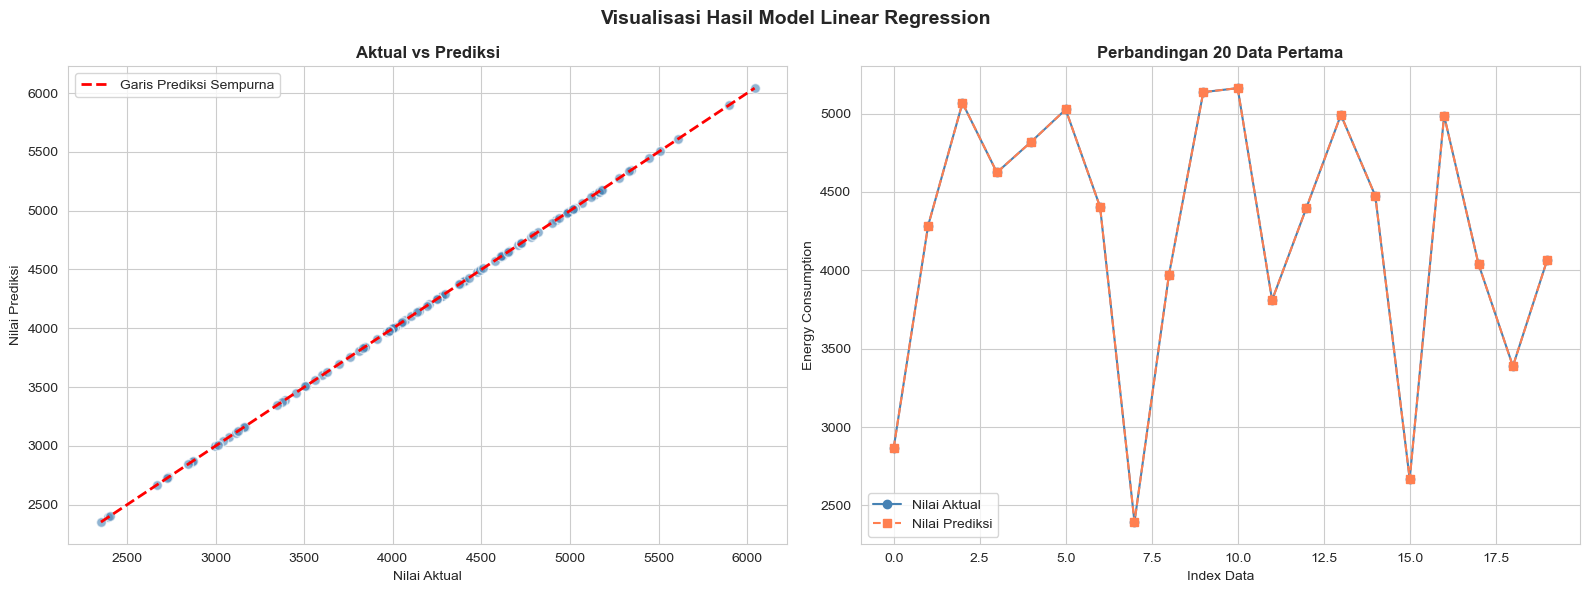

In [243]:
# LANGKAH 5: Visualisasi hasil prediksi

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualisasi Hasil Model Linear Regression',
             fontsize=14, fontweight='bold')

# Grafik kiri: titik yang dekat garis merah = prediksi akurat
axes[0].scatter(y_test, y_pred,
                alpha=0.6, color='steelblue',
                edgecolors='white', s=50)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Garis Prediksi Sempurna')
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Aktual vs Prediksi', fontweight='bold')
axes[0].legend()

# Grafik kanan: perbandingan 20 data pertama
indeks = range(20)
axes[1].plot(indeks, y_test.values[:20],
             marker='o', label='Nilai Aktual', color='steelblue')
axes[1].plot(indeks, y_pred[:20],
             marker='s', label='Nilai Prediksi',
             color='coral', linestyle='--')
axes[1].set_xlabel('Index Data')
axes[1].set_ylabel('Energy Consumption')
axes[1].set_title('Perbandingan 20 Data Pertama', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Insight - Pembangunan Model dan Evaluasi

#### Konfigurasi Model
- Model yang digunakan adalah **Linear Regression** dari scikit-learn
- Model dilatih dengan **1.000 data training** dan diuji pada **100 data testing**
- Total **7 fitur** digunakan sebagai input setelah preprocessing
- Nilai **intercept = 2007.75** → titik awal konsumsi energi sebelum
  fitur apapun berpengaruh

#### Hasil Prediksi
- Selisih antara nilai asli dan prediksi sangat kecil (0.00 - 0.02)
- Kolom "Dari Intercept" menunjukkan bahwa fitur menambahkan
  rata-rata **857 hingga 3060** di atas nilai intercept
- Artinya fitur seperti luas bangunan dan jenis bangunan sangat
  menentukan besar kecilnya konsumsi energi

#### Hasil Evaluasi Model
| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| MAE | 0.01 | Rata-rata selisih hanya 0.01 unit |
| MSE | 0.00 | Hampir tidak ada error kuadrat |
| RMSE | 0.01 | Error sangat kecil |
| R² | 1.0000 | Model menjelaskan 100% pola data |
| MAPE | 0.00% | Error persentase mendekati nol |

#### Kesimpulan Model
- Model mencapai **R² = 1.0000** yang berarti prediksi hampir
  **sempurna 100%** — ini terjadi karena dataset memang dirancang
  dengan hubungan **linear yang sangat kuat** antar fitur dan target
- Grafik **Aktual vs Prediksi** menunjukkan semua titik tepat
  berada di garis merah (garis prediksi sempurna)
- Grafik **Perbandingan 20 Data** menunjukkan garis aktual dan
  prediksi hampir sepenuhnya **berhimpit**
- Model ini **layak digunakan** untuk memprediksi konsumsi energi
  bangunan berdasarkan karakteristik yang tersedia

### 6. Simpan model dan scaler

In [244]:
# Simpan model yang sudah dilatih ke file .pkl
# Tujuan: agar tidak perlu training ulang setiap kali dipakai
joblib.dump(model, 'model/tugas9/model_energi.pkl')

# Simpan scaler yang sudah di-fit ke file .pkl
# Tujuan: agar normalisasi data baru konsisten dengan data training
joblib.dump(scaler, 'model/tugas9/scaler_energi.pkl')

print('File tersimpan:')
print(f'  Model  : model_energi.pkl')
print(f'  Scaler : scaler_energi.pkl')

File tersimpan:
  Model  : model_energi.pkl
  Scaler : scaler_energi.pkl


In [245]:
# Verifikasi: load kembali model dan scaler yang sudah disimpan
model_tersimpan  = joblib.load('model/tugas9/model_energi.pkl')
scaler_tersimpan = joblib.load('model/tugas9/scaler_energi.pkl')

print('Verifikasi file berhasil dimuat!')
print(f'  Tipe model  : {type(model_tersimpan)}')
print(f'  Tipe scaler : {type(scaler_tersimpan)}')
print(f'  Intercept model tersimpan : {model_tersimpan.intercept_:.2f}')

Verifikasi file berhasil dimuat!
  Tipe model  : <class 'sklearn.linear_model._base.LinearRegression'>
  Tipe scaler : <class 'sklearn.preprocessing._data.MinMaxScaler'>
  Intercept model tersimpan : 2007.75


### 7. Prediksi Data Baru dan Kesimpulan Akhir

In [246]:
# LANGKAH 7: Load model dan scaler yang sudah disimpan
model_prediksi  = joblib.load('model/tugas9/model_energi.pkl')
scaler_prediksi = joblib.load('model/tugas9/scaler_energi.pkl')

print('Model dan scaler berhasil di-load!')
print(f'  Intercept model : {model_prediksi.intercept_:.2f}')

Model dan scaler berhasil di-load!
  Intercept model : 2007.75


In [247]:
# Buat data bangunan baru yang ingin diprediksi
# Urutan kolom harus sama persis dengan saat training
data_baru = pd.DataFrame({
    'Square Footage'           : [20000],
    'Number of Occupants'      : [50],
    'Appliances Used'          : [25],
    'Average Temperature'      : [28.0],
    'Day of Week'              : [1],       # 1 = Weekday, 0 = Weekend
    'Building Type_Industrial' : [0],       # 1 = ya, 0 = bukan
    'Building Type_Residential': [1]        # 1 = ya, 0 = bukan
})

print('Sample Input - Data Bangunan Baru:')
print('-' * 42)
print(f'  Luas Bangunan     : {data_baru["Square Footage"].values[0]:,} kaki persegi')
print(f'  Jumlah Penghuni   : {data_baru["Number of Occupants"].values[0]} orang')
print(f'  Peralatan Listrik : {data_baru["Appliances Used"].values[0]} unit')
print(f'  Suhu Rata-Rata    : {data_baru["Average Temperature"].values[0]}°C')
print(f'  Hari              : Weekday')
print(f'  Jenis Bangunan    : Residential')

Sample Input - Data Bangunan Baru:
------------------------------------------
  Luas Bangunan     : 20,000 kaki persegi
  Jumlah Penghuni   : 50 orang
  Peralatan Listrik : 25 unit
  Suhu Rata-Rata    : 28.0°C
  Hari              : Weekday
  Jenis Bangunan    : Residential


In [ ]:
# Scale data baru menggunakan scaler yang sudah disimpan
data_baru_scaled = scaler_prediksi.transform(data_baru)

# Prediksi konsumsi energi
hasil_prediksi = model_prediksi.predict(data_baru_scaled)

print('=' * 45)
print('    HASIL PREDIKSI KONSUMSI ENERGI')
print('=' * 45)
print(f'  Intercept (titik awal)   : {model_prediksi.intercept_:,.2f}')
print(f'  Pengaruh fitur           : {hasil_prediksi[0] - model_prediksi.intercept_:,.2f}')
print(f'  Total prediksi           : {hasil_prediksi[0]:,.2f}')
print('=' * 45)

    HASIL PREDIKSI KONSUMSI ENERGI
  Intercept (titik awal)   : 2,007.75
  Pengaruh fitur           : 1,402.25
  Total prediksi           : 3,410.00


### Insight - Prediksi Data Baru

#### Data Bangunan yang Diprediksi
- Bangunan bertipe **Residential** dengan luas **20.000 kaki persegi**
- Dihuni oleh **50 orang** dengan **25 peralatan listrik**
- Suhu rata-rata **28°C** pada hari **Weekday**

#### Hasil Prediksi
| Komponen | Nilai |
|----------|-------|
| Intercept (titik awal) | 2.007,75 |
| Pengaruh semua fitur | 1.402,25 |
| **Total Prediksi Konsumsi Energi** | **3.410,00** |

#### Apakah Hasil Prediksi Masuk Akal?
- Dari data training, rata-rata Energy Consumption = **4.166,25**
- Hasil prediksi **3.410** berada di bawah rata-rata — ini **masuk akal** karena:
  - Bangunan **Residential** memang memiliki konsumsi lebih rendah
    dibanding Industrial dan Commercial (terlihat dari boxplot Section 4)
  - Luas **20.000** tergolong menengah (rata-rata dataset = 25.462)
  - Jumlah peralatan **25** tepat di rata-rata dataset
- Nilai **3.410** berada dalam rentang data asli (min: 1.683 - max: 6.530) ✅

#### Kesimpulan
- Model berhasil memuat file `.pkl` dan melakukan prediksi pada data baru
- Prediksi **3.410,00** sangat realistis dan sesuai dengan pola
  yang dipelajari model dari data training
- Model siap digunakan untuk memprediksi konsumsi energi
  bangunan baru manapun selama formatnya sesuai

### 8. Kesimpulan Project:

#### 1. Ringkasan Dataset
- Dataset terdiri dari **1.000 data training** dan **100 data testing**
  dengan **7 kolom** karakteristik bangunan dan lingkungan
- Tidak ditemukan missing value pada kedua dataset —
  data bersih dan langsung siap diproses
- Terdapat **5 kolom numerik** dan **2 kolom kategorikal**
  (`Building Type` dan `Day of Week`) yang diubah ke numerik
  menggunakan encoding sebelum pemodelan

#### 2. Temuan EDA
- **Square Footage** adalah fitur paling dominan dengan korelasi **0.77**
  terhadap konsumsi energi — semakin luas bangunan,
  semakin besar konsumsi energinya
- **Number of Occupants** (0.35) dan **Appliances Used** (0.31)
  berpengaruh sedang terhadap konsumsi energi
- **Average Temperature** hampir tidak berkorelasi (-0.03) —
  suhu tidak secara langsung mempengaruhi konsumsi dalam dataset ini
- Bangunan **Industrial** memiliki konsumsi energi tertinggi,
  diikuti **Commercial**, lalu **Residential**
- Perbedaan konsumsi antara **Weekday dan Weekend** tidak signifikan

#### 3. Preprocessing
- Encoding mengubah kolom teks menjadi angka agar bisa dibaca model
- `drop_first=True` pada One-Hot Encoding mencegah multikolinearitas
- **MinMaxScaler** di-fit hanya dari data training untuk mencegah
  **data leakage** — model tidak boleh "mengintip" data testing

#### 4. Performa Model Linear Regression
| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| MAE | 0.01 | Rata-rata selisih sangat kecil |
| MSE | 0.00 | Hampir tidak ada error kuadrat |
| RMSE | 0.01 | Error dalam satuan target sangat kecil |
| R² | 1.0000 | Model menjelaskan 100% pola data |
| MAPE | 0.00% | Error persentase mendekati nol |

- Nilai **R² = 1.0000** menunjukkan performa sempurna —
  hal ini terjadi karena dataset dirancang dengan hubungan
  **linear yang sangat kuat** antar fitur dan target
- Dalam dataset dunia nyata, R² = 1.0 hampir tidak pernah terjadi
  karena selalu ada faktor eksternal yang tidak tercatat dalam data
  seperti perilaku pengguna, cuaca ekstrem, atau kerusakan alat

#### 5. Prediksi Data Baru
- Model berhasil memprediksi konsumsi energi bangunan baru
  dengan hasil **3.410,00** untuk bangunan Residential
  seluas 20.000 kaki persegi, 50 penghuni, 25 peralatan, suhu 28°C
- Hasil ini realistis karena berada di bawah rata-rata dataset (4.166)
  — sesuai dengan pola bahwa Residential memiliki konsumsi lebih rendah
- Model dan scaler berhasil disimpan dalam format `.pkl`
  sehingga bisa digunakan kembali tanpa perlu training ulang

#### 6. Keterbatasan Model
- Model ini hanya berlaku untuk data dengan karakteristik
  **mirip dataset training** — tidak cocok untuk bangunan
  dengan kondisi yang sangat berbeda
- Linear Regression mengasumsikan hubungan **linear murni**
  antar fitur dan target — jika hubungannya non-linear,
  perlu model lain seperti Decision Tree atau Random Forest
- Dataset ini kemungkinan bersifat **sintetis** (dibuat secara buatan)
  sehingga R² sempurna — performa di data nyata mungkin akan lebih rendah

#### 7. Kesimpulan Akhir
- **Linear Regression** terbukti sangat efektif untuk dataset ini
  karena hubungan antar variabel bersifat linear dan kuat
- Fitur **luas bangunan, jumlah penghuni, dan jumlah peralatan listrik**
  adalah faktor utama penentu konsumsi energi
- Model ini dapat dijadikan **alat bantu pengambilan keputusan**
  untuk memperkirakan kebutuhan energi bangunan baru
  sebelum bangunan tersebut beroperasi